In [2]:
%pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 2.5 MB/s  0:00:03 eta 0:00:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 2.2 MB/s  0:00:15m0:00:0100:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [4]:
# Import des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
# plt.style.use('seaborn-v0_8-darkgri')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("ok")

ok


In [6]:
df = pd.read_csv('/home/browngreg/dia3/data_marketing/data_marketing_DIA3/data/transaction_clean.csv')


print(f"Données chargées : {df.shape[0]} lignes et {df.shape[1]} colonnes")
print("\n" + "="*80)
print("Aperçu des premières lignes :")
print("="*80)
df.head()

Données chargées : 1802615 lignes et 11 colonnes

Aperçu des premières lignes :


,invoice_id,customer_id,product_code,product_name,quantity,unit_price,invoice_date,country,from_store,retour_commande,total_price
0,513574,NaN,22382,LUNCH BAG SPACEBOY DESIGN,2.0,4.21,2010-06-25 15:13:00,United Kingdom,yep,non,8.42
1,609421,NaN,21028,PURPLE GEMSTONE BRACELET,2.0,8.95,2011-10-16 12:20:00,United Kingdom,yep,non,17.90
2,515609,NaN,47591B,SCOTTIES CHILDRENS APRON,1.0,1.66,2010-07-13 15:44:00,United Kingdom,yep,non,1.66
3,501320,15123.0,22334,DINOSAUR PARTY BAG + STICKER SET,8.0,1.65,2010-03-16 09:49:00,United Kingdom,no,non,13.20
4,521822,12714.0,21933,PINK VINTAGE PAISLEY PICNIC BAG,5.0,2.95,2010-09-09 10:37:00,France,no,non,14.75


In [50]:
# Info sur les colonnes et les types de données
print("Informations sur le dataset :")
print("="*80)
df.info()
print("\n" + "="*80)
print("Statistiques descriptives :")
print("="*80)
df.describe()

Informations sur le dataset :
<class 'pandas.DataFrame'>
RangeIndex: 1802615 entries, 0 to 1802614
Data columns (total 11 columns):
 #   Column           Dtype  
---  ------           -----  
 0   invoice_id       str    
 1   customer_id      float64
 2   product_code     str    
 3   product_name     str    
 4   quantity         float64
 5   unit_price       float64
 6   invoice_date     str    
 7   country          str    
 8   from_store       str    
 9   retour_commande  str    
 10  total_price      float64
dtypes: float64(4), str(7)
memory usage: 151.3 MB

Statistiques descriptives :


,customer_id,quantity,unit_price,total_price
count,1.392225e+06,1.786429e+06,1.802615e+06,1.786429e+06
mean,2.253993e+04,1.132868e+01,3.868446e+00,2.039547e+01
std,1.262789e+04,1.400710e+02,9.268373e+01,2.313856e+02
min,1.234600e+04,-8.099500e+04,-5.359436e+04,-1.684696e+05
25%,1.491100e+04,1.000000e+00,1.250000e+00,3.750000e+00
50%,1.756100e+04,4.000000e+00,2.100000e+00,1.008000e+01
75%,2.199300e+04,1.200000e+01,3.750000e+00,1.785000e+01
max,6.344100e+04,8.099500e+04,3.897000e+04,1.684696e+05


In [48]:
# Vérif des valeurs manquantes
print("Valeurs manquantes par colonne :")
print("="*80)
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Nombre': missing_values,
    'Pourcentage': missing_percent.round(2)
})
print(missing_df[missing_df['Nombre'] > 0].sort_values('Nombre', ascending=False))

# Nettoyage suppression des lignes sans customer_id
df_clean = df[df['customer_id'].notna()].copy()
print(f"\n✓ Lignes avec customer_id : {len(df_clean)} / {len(df)} ({len(df_clean)/len(df)*100:.1f}%)")

Valeurs manquantes par colonne :
              Nombre  Pourcentage
customer_id   410390        22.77
quantity       16186         0.90
total_price    16186         0.90
product_name    7435         0.41

✓ Lignes avec customer_id : 1392225 / 1802615 (77.2%)


In [47]:
df_clean['invoice_date'] = pd.to_datetime(df_clean['invoice_date'])

print("Période des données :")
print(f"  - Date minimale : {df_clean['invoice_date'].min()}")
print(f"  - Date maximale : {df_clean['invoice_date'].max()}")
print(f"  - Durée : {(df_clean['invoice_date'].max() - df_clean['invoice_date'].min()).days} jours")

print(f"\nNombre de clients uniques : {df_clean['customer_id'].nunique()}")

Période des données :
  - Date minimale : 2007-07-06 12:20:00
  - Date maximale : 2011-12-09 12:50:00
  - Durée : 1617 jours

Nombre de clients uniques : 49146


In [ ]:
# Définition de la date de référence (dernier jour du dataset + 1)
date_reference = df_clean['invoice_date'].max() + pd.Timedelta(days=1)
print(f"Date de référence pour le calcul de la Récence : {date_reference}")

# Calcul des métriques RFM par client
rfm = df_clean.groupby('customer_id').agg({
    'invoice_date': lambda x: (date_reference - x.max()).days, 
    'invoice_id': 'nunique', 
    'total_price': 'sum' 
}).reset_index()

rfm.columns = ['customer_id', 'Recence', 'Frequence', 'Montant']

print(f"\n✓ Métriques RFM calculées pour {len(rfm)} clients")
print("\nAperçu du DataFrame RFM :")
print("="*80)
rfm.head(10)

Date de référence pour le calcul de la Récence : 2011-12-10 12:50:00

✓ Métriques RFM calculées pour 49146 clients

Aperçu du DataFrame RFM :


,customer_id,Recence,Frequence,Montant
0,12346.0,326,17,-51.74
1,12347.0,2,8,4921.53
2,12348.0,75,5,2019.40
3,12349.0,19,5,4404.54
4,12350.0,310,1,334.40
5,12351.0,375,1,300.93
6,12352.0,36,13,1889.21
7,12353.0,204,2,406.76
8,12354.0,232,1,1079.40
9,12355.0,214,2,947.61


In [46]:
# Statistiques des métriques RFM
print("Statistiques descriptives des métriques RFM :")
print("="*80)
rfm[['Recence', 'Frequence', 'Montant']].describe()

Statistiques descriptives des métriques RFM :


,Recence,Frequence,Montant
count,49146.000000,49146.000000,49146.00000
mean,360.263379,4.646889,607.38078
std,317.311321,10.152721,4904.53931
min,1.000000,1.000000,-25111.09000
25%,88.000000,1.000000,28.20000
50%,270.000000,2.000000,84.65000
75%,568.000000,5.000000,327.49500
max,1618.000000,510.000000,570380.61000


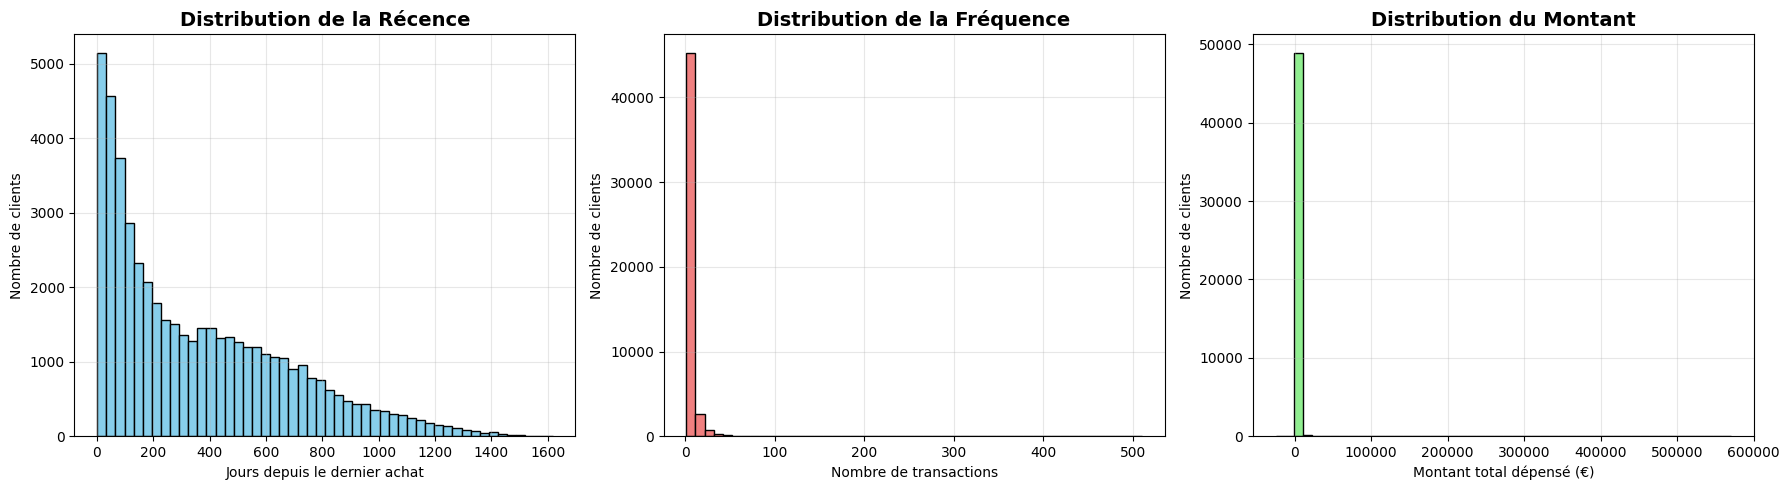

In [12]:
# Histogrammes des distributions RFM
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(rfm['Recence'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Distribution de la Récence', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Jours depuis le dernier achat')
axes[0].set_ylabel('Nombre de clients')
axes[0].grid(alpha=0.3)

axes[1].hist(rfm['Frequence'], bins=50, color='lightcoral', edgecolor='black')
axes[1].set_title('Distribution de la Fréquence', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Nombre de transactions')
axes[1].set_ylabel('Nombre de clients')
axes[1].grid(alpha=0.3)

axes[2].hist(rfm['Montant'], bins=50, color='lightgreen', edgecolor='black')
axes[2].set_title('Distribution du Montant', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Montant total dépensé (€)')
axes[2].set_ylabel('Nombre de clients')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

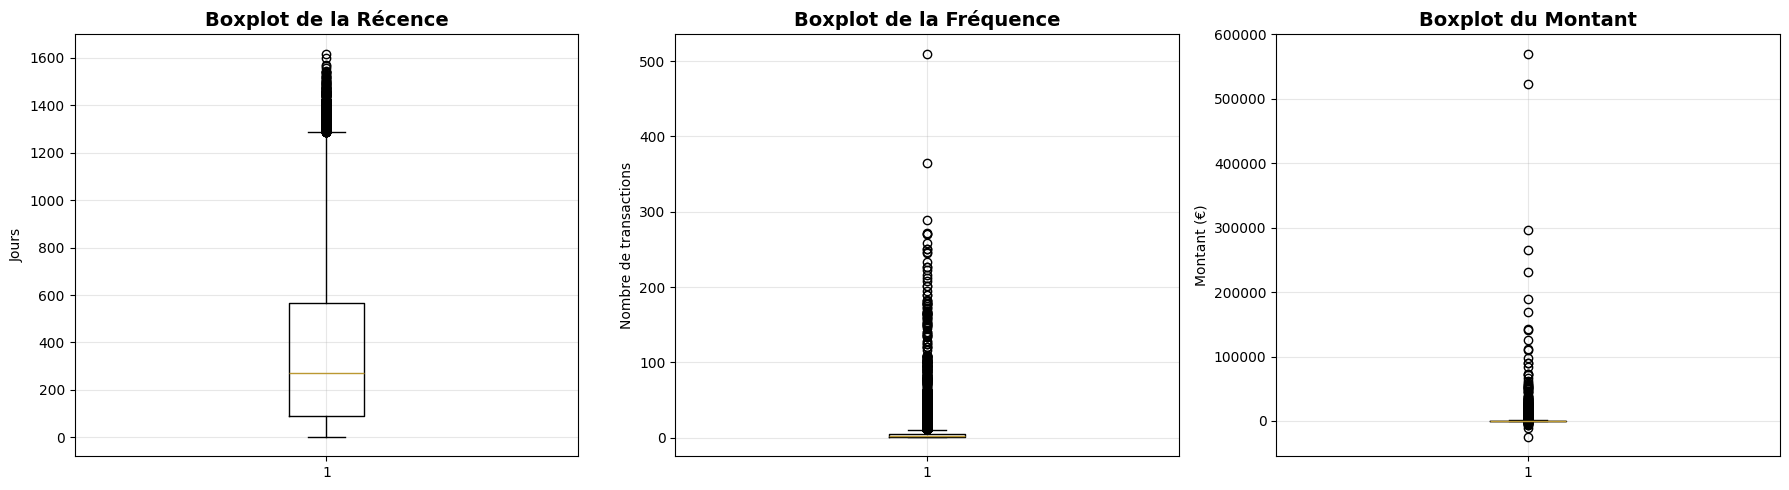

In [13]:
# Boxplots pour identifier les valeurs aberrantes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].boxplot(rfm['Recence'], vert=True)
axes[0].set_title('Boxplot de la Récence', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jours')
axes[0].grid(alpha=0.3)

axes[1].boxplot(rfm['Frequence'], vert=True)
axes[1].set_title('Boxplot de la Fréquence', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Nombre de transactions')
axes[1].grid(alpha=0.3)

axes[2].boxplot(rfm['Montant'], vert=True)
axes[2].set_title('Boxplot du Montant', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Montant (€)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

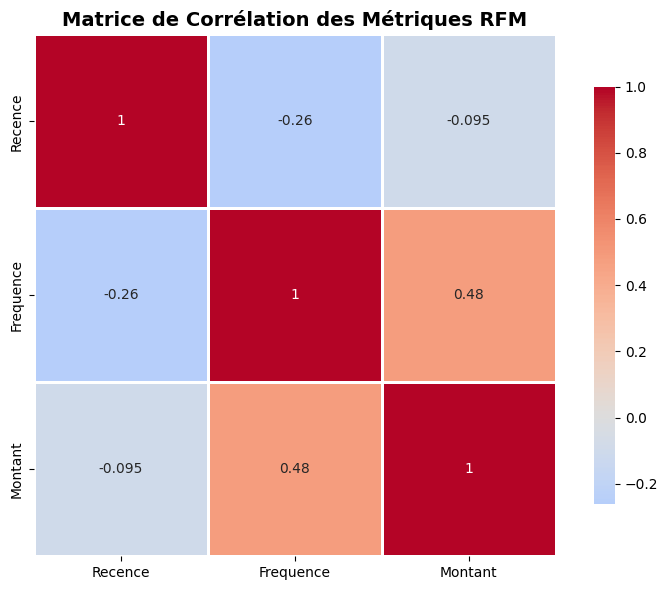


Analyse de corrélation :
            Recence  Frequence   Montant
Recence    1.000000  -0.261456 -0.095411
Frequence -0.261456   1.000000  0.478335
Montant   -0.095411   0.478335  1.000000


In [14]:
# Matrice de corrélation entre les métriques RFM
correlation_matrix = rfm[['Recence', 'Frequence', 'Montant']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matrice de Corrélation des Métriques RFM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nAnalyse de corrélation :")
print("="*80)
print(correlation_matrix)

In [15]:
# Calcul des scores RFM en quintiles (1-5)
# Note : Pour Récence, un score élevé = faible récence (meilleur)
rfm['R_Score'] = pd.qcut(rfm['Recence'], q=5, labels=[5, 4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequence'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Montant'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])

# Conversion en entiers
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

# Score RFM combiné (simple concaténation)
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Score RFM agrégé (moyenne)
rfm['RFM_Score_Total'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

print("Scores RFM calculés ✓")
print("\nAperçu des scores :")
rfm[['customer_id', 'Recence', 'Frequence', 'Montant', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Score_Total']].head(10)

Scores RFM calculés ✓

Aperçu des scores :


,customer_id,Recence,Frequence,Montant,R_Score,F_Score,M_Score,RFM_Score,RFM_Score_Total
0,12346.0,326,17,-51.74,3,5,1,351,9
1,12347.0,2,8,4921.53,5,5,5,555,15
2,12348.0,75,5,2019.40,4,4,5,445,13
3,12349.0,19,5,4404.54,5,4,5,545,14
4,12350.0,310,1,334.40,3,1,4,314,8
5,12351.0,375,1,300.93,3,1,4,314,8
6,12352.0,36,13,1889.21,5,5,5,555,15
7,12353.0,204,2,406.76,3,3,4,334,10
8,12354.0,232,1,1079.40,3,1,5,315,9
9,12355.0,214,2,947.61,3,3,5,335,11


In [45]:
# RFM
def segment_rfm(row):
    """Assigne un segment client basé sur les scores RFM"""
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    
    elif r >= 3 and f >= 4:
        return 'Clients Fidèles'
    
    elif r >= 4 and f <= 2:
        return 'Clients Potentiels'
    
    elif r <= 2 and f >= 3:
        return 'À Risque'
    
    elif r <= 2 and f >= 2 and f <= 3:
        return 'Endormis'
    
    elif r <= 2 and f <= 2:
        return 'Perdus'
    
    else:
        return 'Occasionnels'

# Application de la segmentation
rfm['Segment'] = rfm.apply(segment_rfm, axis=1)

print("Segmentation RFM réalisée ✓")
print("\nDistribution des segments :")
print("="*80)
segment_counts = rfm['Segment'].value_counts().sort_values(ascending=False)
print(segment_counts)
print(f"\nTotal : {segment_counts.sum()} clients")

Segmentation RFM réalisée ✓

Distribution des segments :
Segment
Champions             9756
Occasionnels          8820
Perdus                8174
À Risque              7074
Clients Fidèles       6739
Endormis              4391
Clients Potentiels    4192
Name: count, dtype: int64

Total : 49146 clients


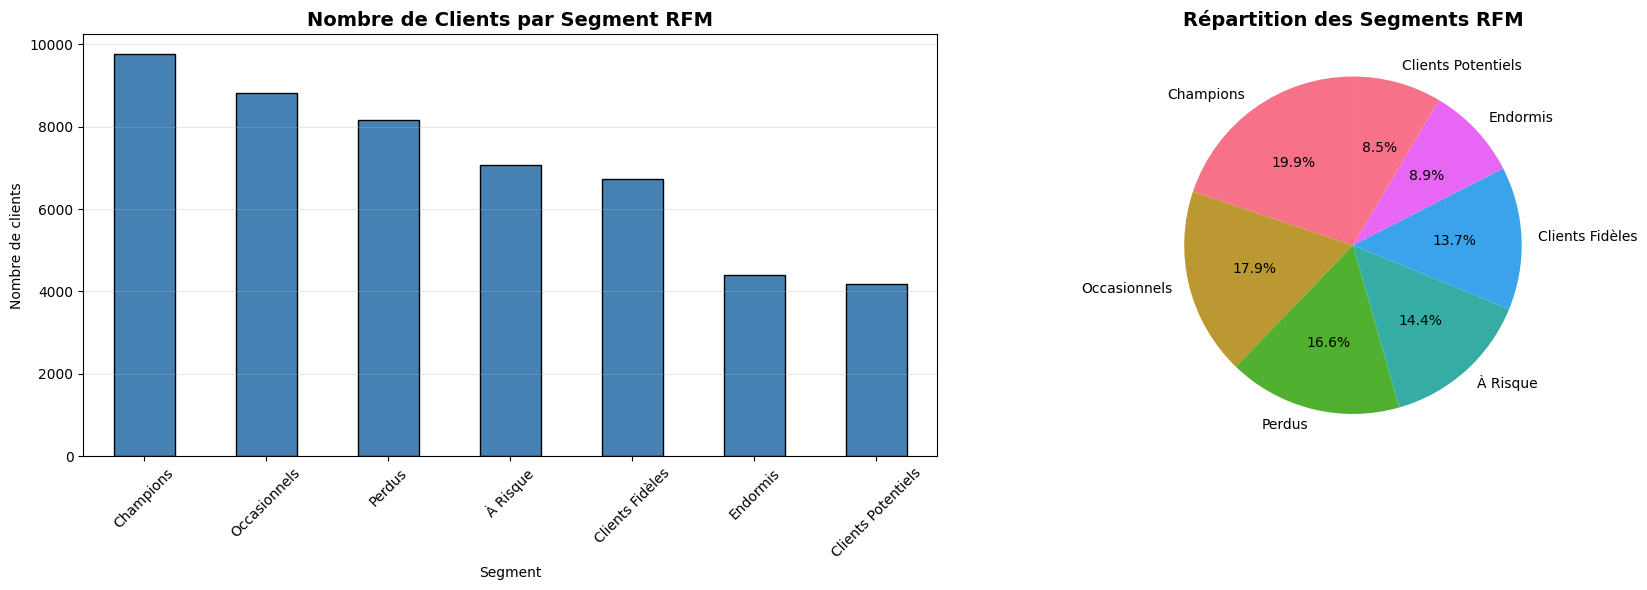

In [ ]:
# Viz de la distribution des segments
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Diagramme barre
segment_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Nombre de Clients par Segment RFM', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Nombre de clients')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.3, axis='y')

# Diagramme rond
segment_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Répartition des Segments RFM', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [43]:
# Statistiques moyennes par segment
segment_stats = rfm.groupby('Segment')[['Recence', 'Frequence', 'Montant']].mean().round(2)
segment_stats['Nombre_Clients'] = rfm.groupby('Segment').size()
segment_stats = segment_stats.sort_values('Nombre_Clients', ascending=False)

print("Profil moyen de chaque segment :")
print("="*80)
segment_stats

Profil moyen de chaque segment :


,Recence,Frequence,Montant,Nombre_Clients
Segment,,,,
Champions,69.33,13.72,2312.92,9756
Occasionnels,200.75,1.79,160.24,8820
Perdus,744.88,1.00,40.16,8174
À Risque,586.29,3.36,301.70,7074
Clients Fidèles,207.20,5.68,426.62,6739
Endormis,751.13,1.00,66.80,4391
Clients Potentiels,78.23,1.00,57.58,4192


In [44]:
features = ['Recence', 'Frequence', 'Montant']
X = rfm[features].copy()

print("Données avant normalisation :")
print("="*80)
print(X.describe())

# Normalisation StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# DataFrame pour visualisation
X_scaled_df = pd.DataFrame(X_scaled, columns=[f'{col}_scaled' for col in features])

print("\n" + "="*80)
print("Données après normalisation (StandardScaler) :")
print("="*80)
print(X_scaled_df.describe())

print("\n✓ Normalisation effectuée avec succès")

Données avant normalisation :
            Recence     Frequence       Montant
count  49146.000000  49146.000000   49146.00000
mean     360.263379      4.646889     607.38078
std      317.311321     10.152721    4904.53931
min        1.000000      1.000000  -25111.09000
25%       88.000000      1.000000      28.20000
50%      270.000000      2.000000      84.65000
75%      568.000000      5.000000     327.49500
max     1618.000000    510.000000  570380.61000

Données après normalisation (StandardScaler) :
       Recence_scaled  Frequence_scaled  Montant_scaled
count    4.914600e+04      4.914600e+04    4.914600e+04
mean    -9.252988e-18      3.701195e-17   -1.850598e-17
std      1.000010e+00      1.000010e+00    1.000010e+00
min     -1.132223e+00     -3.592067e-01   -5.243863e+00
25%     -8.580411e-01     -3.592067e-01   -1.180920e-01
50%     -2.844660e-01     -2.607100e-01   -1.065821e-01
75%      6.546843e-01      3.478030e-02   -5.706726e-02
max      3.963771e+00      4.977564e+01   

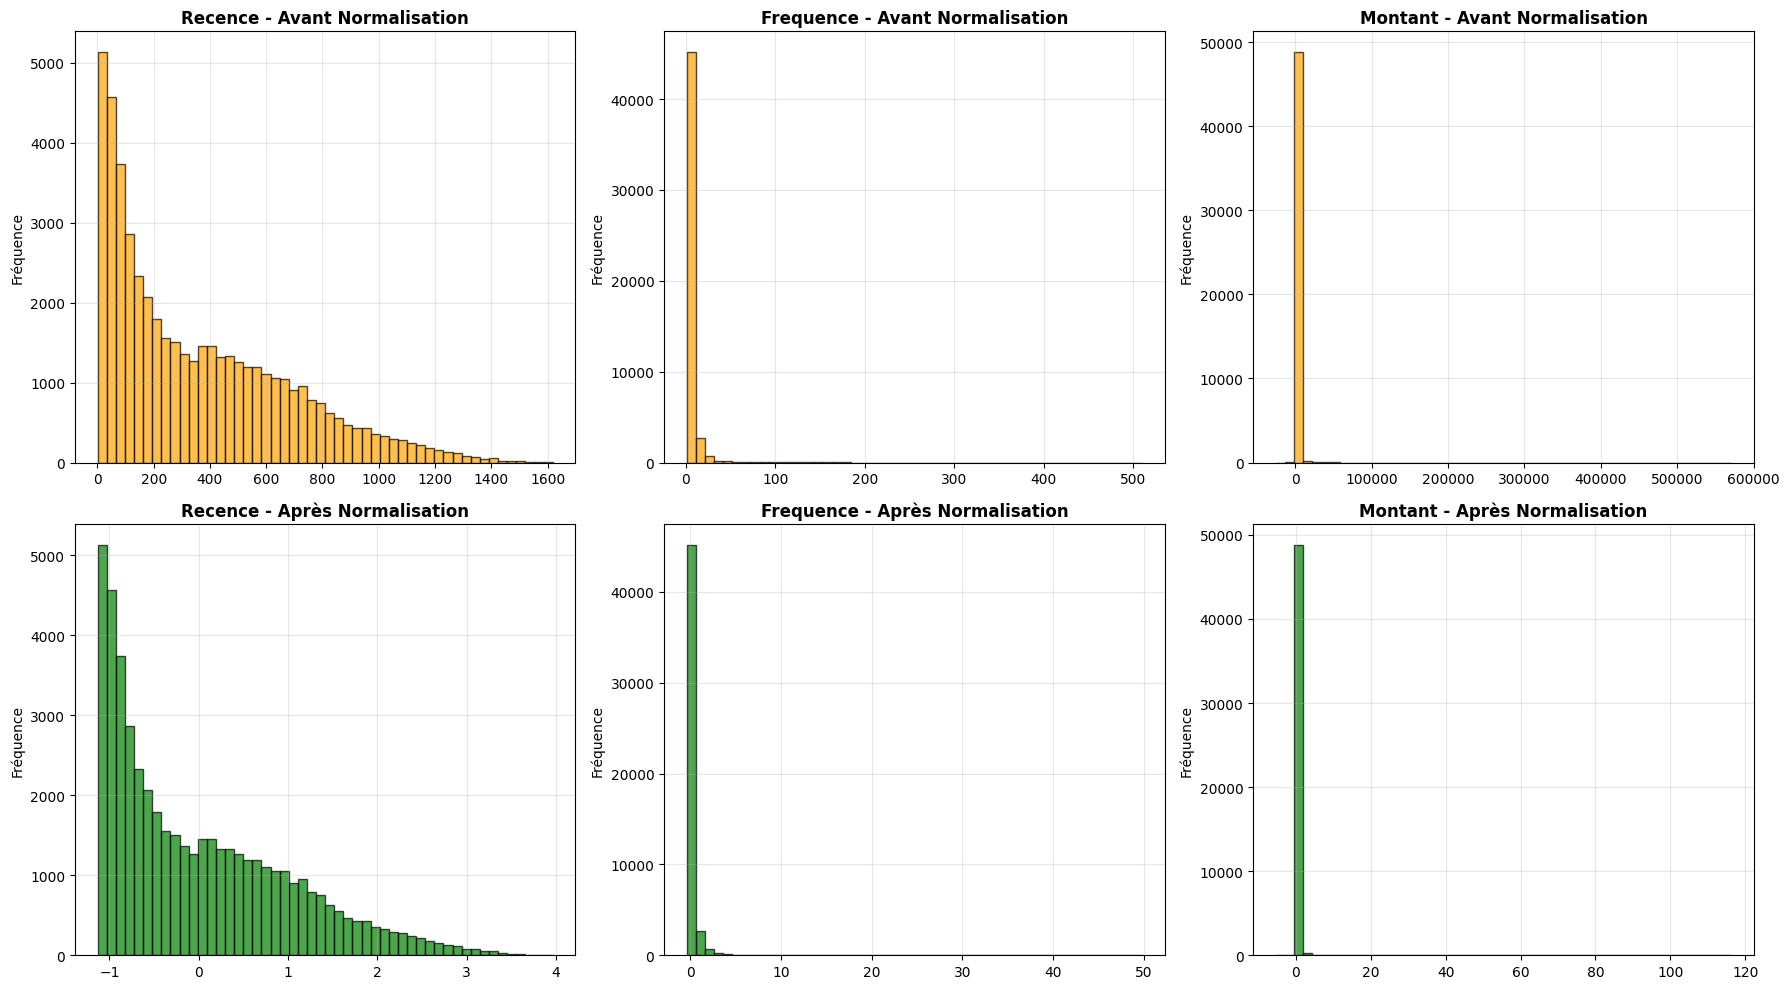

In [18]:
# Visualisation avant/après normalisation
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, col in enumerate(features):
    # Avant normalisation
    axes[0, i].hist(X[col], bins=50, color='orange', edgecolor='black', alpha=0.7)
    axes[0, i].set_title(f'{col} - Avant Normalisation', fontsize=12, fontweight='bold')
    axes[0, i].set_ylabel('Fréquence')
    axes[0, i].grid(alpha=0.3)
    
    # Après normalisation
    axes[1, i].hist(X_scaled[:, i], bins=50, color='green', edgecolor='black', alpha=0.7)
    axes[1, i].set_title(f'{col} - Après Normalisation', fontsize=12, fontweight='bold')
    axes[1, i].set_ylabel('Fréquence')
    axes[1, i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
# Méthode du coude (Elbow Method)
inertias = []
silhouette_scores = []
K_range = range(2, 11)

print("Calcul de l'inertie et du score de silhouette pour différents nombres de clusters...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    print(f"  k={k} : Inertie={kmeans.inertia_:.2f}, Silhouette={silhouette_scores[-1]:.4f}")

print("\n✓ Calculs terminés")

Calcul de l'inertie et du score de silhouette pour différents nombres de clusters...
  k=2 : Inertie=109200.61, Silhouette=0.5034
  k=3 : Inertie=75283.90, Silhouette=0.5254
  k=4 : Inertie=49824.01, Silhouette=0.5283
  k=5 : Inertie=39295.73, Silhouette=0.5439
  k=6 : Inertie=32103.10, Silhouette=0.4914
  k=7 : Inertie=25606.42, Silhouette=0.4938
  k=8 : Inertie=21189.81, Silhouette=0.4935
  k=9 : Inertie=18624.28, Silhouette=0.4614
  k=10 : Inertie=16300.87, Silhouette=0.4615

✓ Calculs terminés


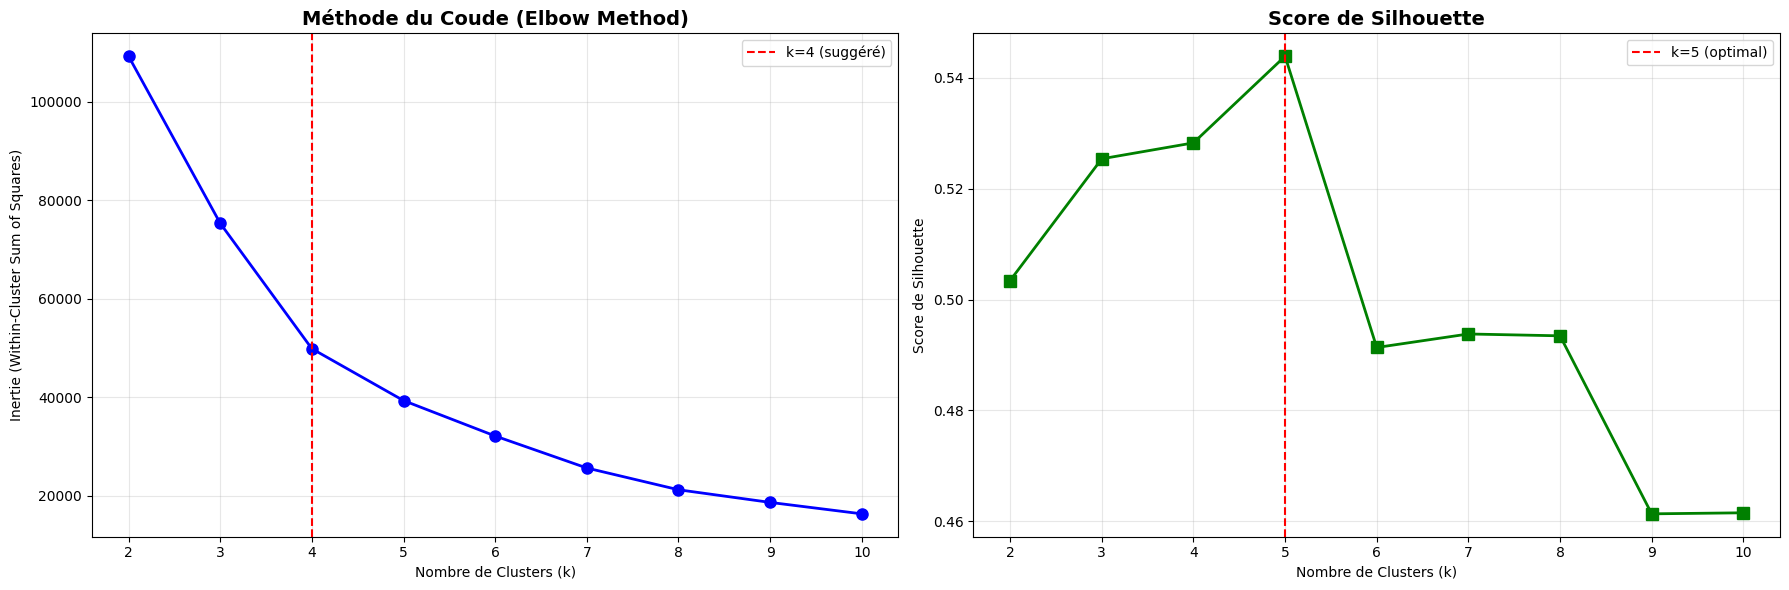


Meilleur nombre de clusters selon le score de silhouette : 5


In [25]:
# Visualisation de la méthode du coude et du score de silhouette
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Méthode du coude
axes[0].plot(K_range, inertias, marker='o', linewidth=2, markersize=8, color='blue')
axes[0].set_title('Méthode du Coude (Elbow Method)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Nombre de Clusters (k)')
axes[0].set_ylabel('Inertie (Within-Cluster Sum of Squares)')
axes[0].grid(alpha=0.3)
axes[0].axvline(x=4, color='red', linestyle='--', label='k=4 (suggéré)')
axes[0].legend()

# Score de silhouette
axes[1].plot(K_range, silhouette_scores, marker='s', linewidth=2, markersize=8, color='green')
axes[1].set_title('Score de Silhouette', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Nombre de Clusters (k)')
axes[1].set_ylabel('Score de Silhouette')
axes[1].grid(alpha=0.3)

# Trouver le meilleur k selon le score de silhouette
best_k = K_range[np.argmax(silhouette_scores)]
axes[1].axvline(x=best_k, color='red', linestyle='--', label=f'k={best_k} (optimal)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nMeilleur nombre de clusters selon le score de silhouette : {best_k}")

In [39]:
# K-Means
optimal_k = 4 #mais on peut ajuster selon les résultats 

kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
rfm['Cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"✓ K-Means appliqué avec {optimal_k} clusters")
print(f"\nInertie finale : {kmeans_final.inertia_:.2f}")
print(f"Score de silhouette final : {silhouette_score(X_scaled, rfm['Cluster']):.4f}")

print("\nDistribution des clusters :")
print("="*80)
print(rfm['Cluster'].value_counts().sort_index())

✓ K-Means appliqué avec 4 clusters

Inertie finale : 49824.01
Score de silhouette final : 0.5283

Distribution des clusters :
Cluster
0    17623
1      197
2    31321
3        5
Name: count, dtype: int64


In [38]:
# Profil moyen pour chaque cluster
cluster_profile = rfm.groupby('Cluster')[['Recence', 'Frequence', 'Montant']].mean().round(2)
cluster_profile['Nombre_Clients'] = rfm.groupby('Cluster').size()
cluster_profile['Pourcentage'] = (cluster_profile['Nombre_Clients'] / len(rfm) * 100).round(2)

print("Profil des Clusters :")
print("="*80)
cluster_profile

Profil des Clusters :


,Recence,Frequence,Montant,Nombre_Clients,Pourcentage
Cluster,,,,,
0,720.89,1.62,111.71,17623,35.86
1,41.44,115.79,24638.15,197,0.40
2,159.42,5.62,674.98,31321,63.73
3,4.40,218.00,377386.92,5,0.01


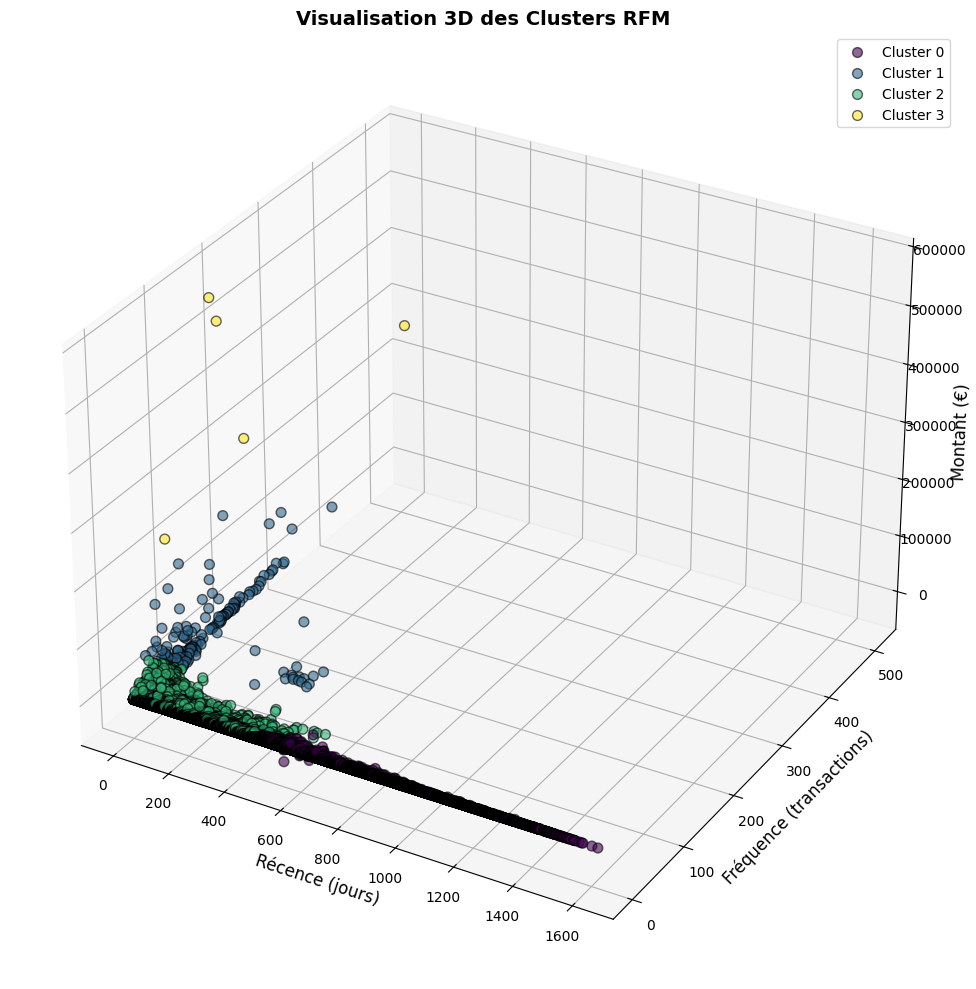

In [37]:
# Visualisation 3D des clusters
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# coloriage des clusters
colors = plt.cm.viridis(np.linspace(0, 1, optimal_k))

for cluster in range(optimal_k):
    cluster_data = rfm[rfm['Cluster'] == cluster]
    ax.scatter(cluster_data['Recence'], 
               cluster_data['Frequence'], 
               cluster_data['Montant'],
               c=[colors[cluster]], 
               label=f'Cluster {cluster}',
               s=50, 
               alpha=0.6,
               edgecolors='black')

ax.set_xlabel('Récence (jours)', fontsize=12)
ax.set_ylabel('Fréquence (transactions)', fontsize=12)
ax.set_zlabel('Montant (€)', fontsize=12)
ax.set_title('Visualisation 3D des Clusters RFM', fontsize=14, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

Variance expliquée par les 2 premières composantes principales :
  - PC1 : 52.96%
  - PC2 : 30.68%
  - Total : 83.64%


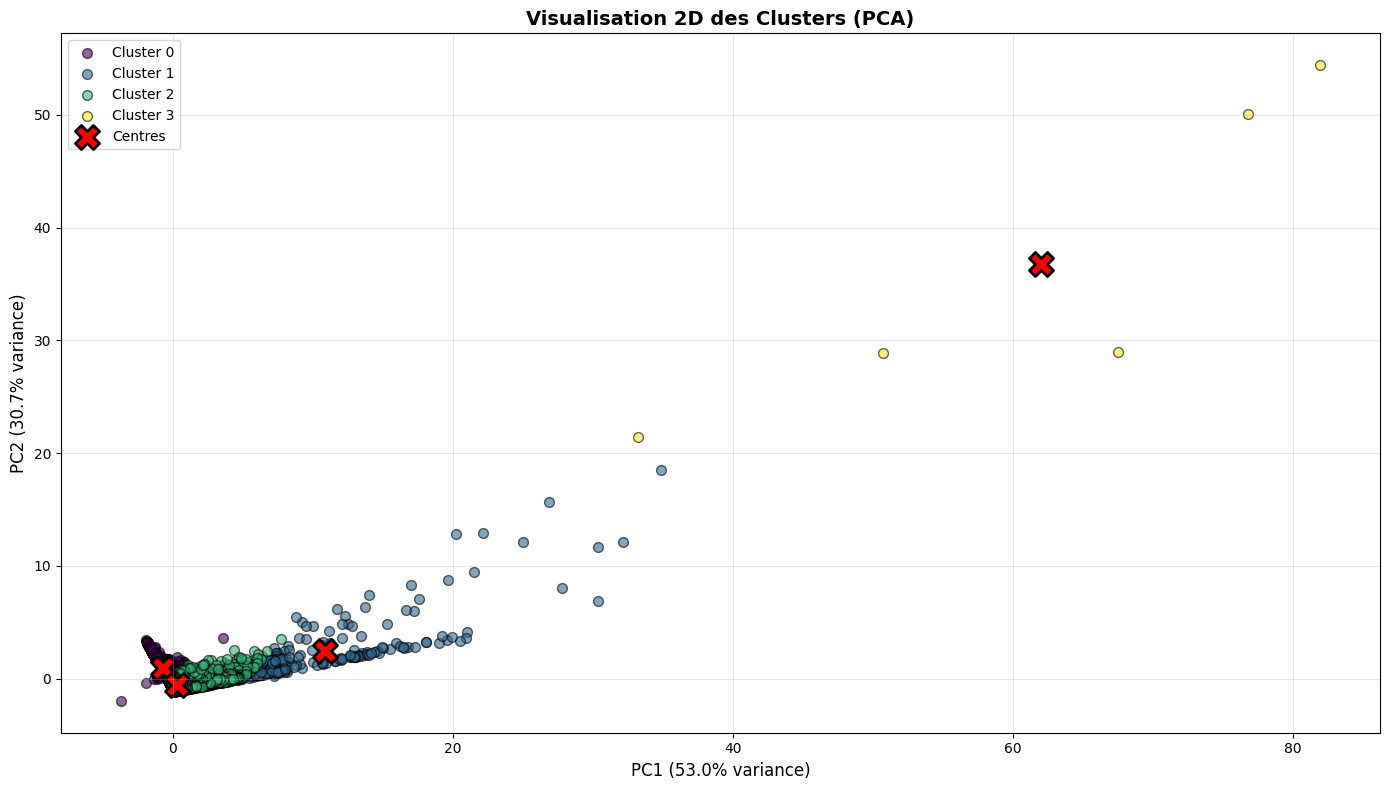

In [36]:
# Réduction de dimensionnalité avec PCA pour visualisation 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance expliquée par les 2 premières composantes principales :")
print(f"  - PC1 : {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"  - PC2 : {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"  - Total : {sum(pca.explained_variance_ratio_)*100:.2f}%")

# 2D viz avec la PCA
plt.figure(figsize=(14, 8))

for cluster in range(optimal_k):
    cluster_mask = rfm['Cluster'] == cluster
    plt.scatter(X_pca[cluster_mask, 0], 
                X_pca[cluster_mask, 1], 
                c=[colors[cluster]],
                label=f'Cluster {cluster}',
                s=50, 
                alpha=0.6,
                edgecolors='black')

# affichage des centres des clusters
centers_pca = pca.transform(kmeans_final.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], 
            c='red', marker='X', s=300, edgecolors='black', 
            linewidths=2, label='Centres')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.title('Visualisation 2D des Clusters (PCA)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

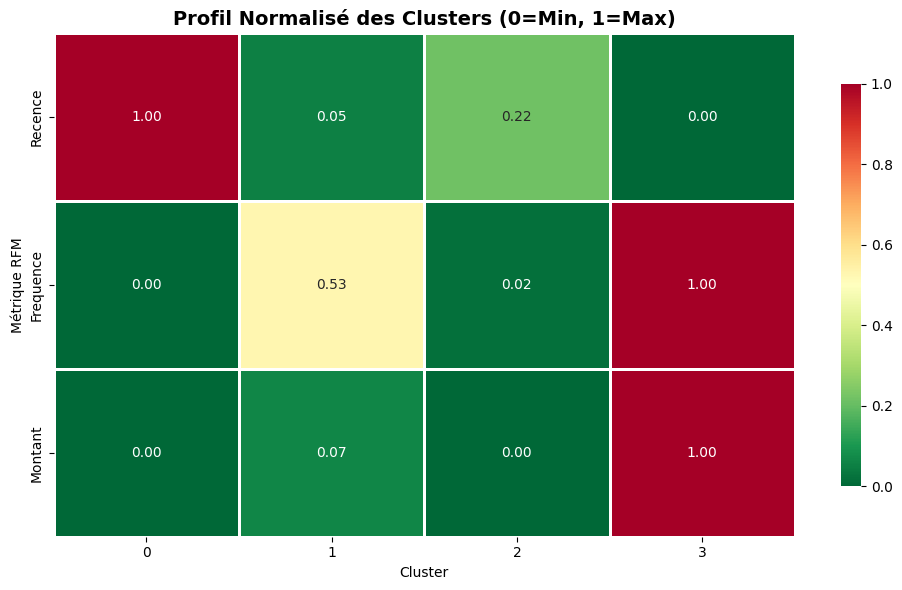

In [33]:
cluster_means_normalized = rfm.groupby('Cluster')[['Recence', 'Frequence', 'Montant']].mean()

# Normalisation min-max
from sklearn.preprocessing import MinMaxScaler
scaler_heatmap = MinMaxScaler()
cluster_means_normalized_values = scaler_heatmap.fit_transform(cluster_means_normalized)
cluster_means_normalized = pd.DataFrame(
    cluster_means_normalized_values,
    columns=cluster_means_normalized.columns,
    index=cluster_means_normalized.index
)

plt.figure(figsize=(10, 6))
sns.heatmap(cluster_means_normalized.T, annot=True, fmt='.2f', cmap='RdYlGn_r', 
            linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Profil Normalisé des Clusters (0=Min, 1=Max)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Métrique RFM')
plt.tight_layout()
plt.show()

In [35]:
# Fonction pour nommer et interpréter les clusters
def interpreter_cluster(cluster_id, profile):
    """Interprète un cluster basé sur son profil RFM"""
    r = profile['Recence']
    f = profile['Frequence']
    m = profile['Montant']
    
    interpretations = {
        'nom': f'Cluster {cluster_id}',
        'description': '',
        'strategie': ''
    }
    
    # interprétation basée sur les moyennes
    if r < 100 and f > 100 and m > 2000:
        interpretations['nom'] = 'Champions'
        interpretations['description'] = 'Clients très actifs, achats récents, fréquents et montants élevés'
        interpretations['strategie'] = 'Programme VIP, offres exclusives, récompenses de fidélité'
    
    elif r < 150 and f > 50:
        interpretations['nom'] = 'Clients Fidèles'
        interpretations['description'] = 'Clients réguliers avec bonne récence et fréquence'
        interpretations['strategie'] = 'Cross-selling, upselling, recommandations personnalisées'
    
    elif r > 200 and m > 1000:
        interpretations['nom'] = 'Clients à Réactiver'
        interpretations['description'] = 'Clients de valeur mais inactifs depuis longtemps'
        interpretations['strategie'] = 'Campagnes de réactivation, offres de retour, enquêtes de satisfaction'
    
    elif f < 30 and m < 500:
        interpretations['nom'] = 'Nouveaux/Occasionnels'
        interpretations['description'] = 'Clients peu actifs ou nouveaux'
        interpretations['strategie'] = 'Onboarding, incentives pour premier achat, programmes de bienvenue'
    
    else:
        interpretations['nom'] = f'Segment {cluster_id}'
        interpretations['description'] = 'Profil mixte nécessitant une analyse approfondie'
        interpretations['strategie'] = 'Segmentation supplémentaire recommandée'
    
    return interpretations

# interprétation des clusters
interpretations = []
for cluster_id in range(optimal_k):
    profile = cluster_profile.loc[cluster_id]
    interp = interpreter_cluster(cluster_id, profile)
    interp['cluster_id'] = cluster_id
    interp['nb_clients'] = profile['Nombre_Clients']
    interp['pourcentage'] = profile['Pourcentage']
    interp['recence_moy'] = profile['Recence']
    interp['frequence_moy'] = profile['Frequence']
    interp['montant_moy'] = profile['Montant']
    interpretations.append(interp)

interp_df = pd.DataFrame(interpretations)

print("Interprétation des Clusters :")
print("="*80)
for _, row in interp_df.iterrows():
    print(f"\n🔹 {row['nom']} (Cluster {row['cluster_id']})")
    print(f"   Clients : {row['nb_clients']} ({row['pourcentage']}%)")
    print(f"   Profil : R={row['recence_moy']:.0f}j, F={row['frequence_moy']:.0f}, M={row['montant_moy']:.0f}€")
    print(f"   Description : {row['description']}")
    print(f"   Stratégie : {row['strategie']}")

Interprétation des Clusters :

🔹 Nouveaux/Occasionnels (Cluster 0)
   Clients : 17623.0 (35.86%)
   Profil : R=721j, F=2, M=112€
   Description : Clients peu actifs ou nouveaux
   Stratégie : Onboarding, incentives pour premier achat, programmes de bienvenue

🔹 Champions (Cluster 1)
   Clients : 197.0 (0.4%)
   Profil : R=41j, F=116, M=24638€
   Description : Clients très actifs, achats récents, fréquents et montants élevés
   Stratégie : Programme VIP, offres exclusives, récompenses de fidélité

🔹 Segment 2 (Cluster 2)
   Clients : 31321.0 (63.73%)
   Profil : R=159j, F=6, M=675€
   Description : Profil mixte nécessitant une analyse approfondie
   Stratégie : Segmentation supplémentaire recommandée

🔹 Champions (Cluster 3)
   Clients : 5.0 (0.01%)
   Profil : R=4j, F=218, M=377387€
   Description : Clients très actifs, achats récents, fréquents et montants élevés
   Stratégie : Programme VIP, offres exclusives, récompenses de fidélité


In [ ]:
# Récap des segements
summary_df = interp_df[['cluster_id', 'nom', 'nb_clients', 'pourcentage', 
                         'recence_moy', 'frequence_moy', 'montant_moy']].copy()
summary_df.columns = ['Cluster', 'Nom', 'Nb Clients', '%', 'Récence Moy', 'Fréquence Moy', 'Montant Moy']
summary_df = summary_df.sort_values('Nb Clients', ascending=False)

print("\n" + "="*80)
print("TABLEAU RÉCAPITULATIF DES SEGMENTS")
print("="*80)
summary_df


TABLEAU RÉCAPITULATIF DES SEGMENTS


,Cluster,Nom,Nb Clients,%,Récence Moy,Fréquence Moy,Montant Moy
2,2,Segment 2,31321.0,63.73,159.42,5.62,674.98
0,0,Nouveaux/Occasionnels,17623.0,35.86,720.89,1.62,111.71
1,1,Champions,197.0,0.40,41.44,115.79,24638.15
3,3,Champions,5.0,0.01,4.40,218.00,377386.92
